In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

matplotlib.rcParams['pdf.fonttype'] = 42


In [ ]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/homozygous_JAK2_mrvi_patient_as_nuisance.h5ad')

In [ ]:
patient_metadata = pd.read_csv('../data/patient_diagnoses.csv', index_col=0)
sample_to_diagnosis = patient_metadata['Diagnosis '].to_dict()

In [6]:
color_palette = {}
for i, cell_type in enumerate(adata.obs['cell_type'].cat.categories):
    color_palette[cell_type] = adata.uns['cell_type_colors'][i]

In [7]:
min_cells = 20

n_cells = adata.obs.groupby(['sample','cell_type'],observed=False).size().reset_index()
n_cells.rename(columns={0: 'n_cells'}, inplace=True)

df = adata.obs.groupby(['sample','cell_type'],observed=False)['genotype'].value_counts(normalize=True).reset_index()
df = df.loc[df['genotype'] == 'mutated']

df = df.merge(n_cells, on = ['sample','cell_type'], how='left')

df = df.loc[df['n_cells'] > min_cells].copy()

baseline = adata.obs.groupby(['sample'],observed=False)['genotype'].value_counts(normalize=True).reset_index()
baseline = baseline.loc[baseline['genotype'] == 'mutated']

df = df.merge(baseline[['sample','proportion']], on='sample', suffixes=('_cell_type', '_baseline'), how='left')


# df['proportion_cell_type'] = df['proportion_cell_type'] + (0.1 / df['n_cells'])
df['lfc'] = np.log10((df['proportion_cell_type'] / df['proportion_baseline']) )

df['diagnosis'] = df['sample'].map(sample_to_diagnosis)

cell_types_to_include = []
for cell_type in df['cell_type'].unique():
    p = st.wilcoxon(df.loc[df['cell_type'] == cell_type]['proportion_cell_type'], df.loc[df['cell_type'] == cell_type]['proportion_baseline'], alternative='two-sided').pvalue
    if p < 0.15:
        cell_types_to_include.append(cell_type)


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/tmp/ipykernel_1571842/1474920296.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df.groupby('cell_type')['lfc'].median().dropna().sort_values()


diagnosis
PMF          2
PV           3
postET MF    2
postPV MF    2
Name: sample, dtype: int64


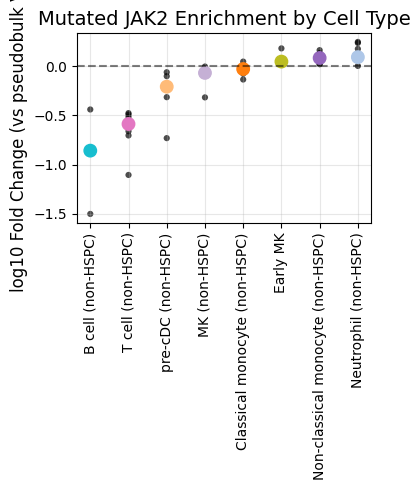

In [9]:
df = df[df['cell_type'].isin(cell_types_to_include)]
df['lfc'] = df['lfc'].replace(-np.inf, -1.5)

# Create the plot
fig, ax = plt.subplots(figsize=(4,5))

medians = df.groupby('cell_type')['lfc'].median().dropna().sort_values()
colors = [color_palette[ct] for ct in medians.index]

ax.scatter(medians.index, medians, s=80, color=colors, zorder=2, alpha=1)

# Plot each sample as a different colored line/scatter
ax.scatter(df['cell_type'], df['lfc'], s=20, color='k', alpha=0.7, zorder=1, edgecolors='none')

# Customize the plot
ax.set_ylabel('log10 Fold Change (vs pseudobulk VAF)', fontsize=12)
ax.set_title('Mutated JAK2 Enrichment by Cell Type', fontsize=14)
ax.tick_params(axis='x', rotation=90)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Reference line at 0
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()

print(df.groupby('diagnosis')['sample'].nunique())

plt.savefig('../plots/JAK2_mutation_DA_by_cell_type.pdf', bbox_inches='tight')